In [ ]:
!pip install opencv-python opencv-contrib-python

from google.colab import files
uploaded = files.upload()

import os, shutil
os.makedirs("images/panorama_set", exist_ok=True)

for file in uploaded.keys():
    shutil.move(file, "images/panorama_set/" + file)

Saving dot1.jpeg to dot1.jpeg
Saving dot2.jpeg to dot2.jpeg
Saving dot3.jpeg to dot3.jpeg
Saving dot4.jpeg to dot4.jpeg
Saving dot5.jpeg to dot5.jpeg
Saving dot6.jpeg to dot6.jpeg
Saving dot7.jpeg to dot7.jpeg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from pathlib import Path
from typing import List

In [ ]:
IMAGE_FOLDER = "images/panorama_set"
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

def load_images(folder: str):
    images = []
    for file in sorted(os.listdir(folder)):
        if Path(file).suffix.lower() in IMAGE_EXTENSIONS:
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)
            if img is not None:
                images.append(img)
                print(f"Loaded: {file}  shape: {img.shape}")
    return images


def show_images(images, titles=None, figsize=(15,6)):
    n = len(images)

    plt.figure(figsize=figsize)

    for i,img in enumerate(images):
        plt.subplot(1,n,i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {i+1}")
        plt.axis("off")

    plt.show()

Loaded: dot1.jpeg  shape: (1600, 1200, 3)
Loaded: dot2.jpeg  shape: (1600, 1200, 3)
Loaded: dot3.jpeg  shape: (1600, 1200, 3)
Loaded: dot4.jpeg  shape: (1600, 1200, 3)
Loaded: dot5.jpeg  shape: (1600, 1200, 3)
Loaded: dot6.jpeg  shape: (1600, 1200, 3)
Loaded: dot7.jpeg  shape: (1600, 1200, 3)
Total images: 7


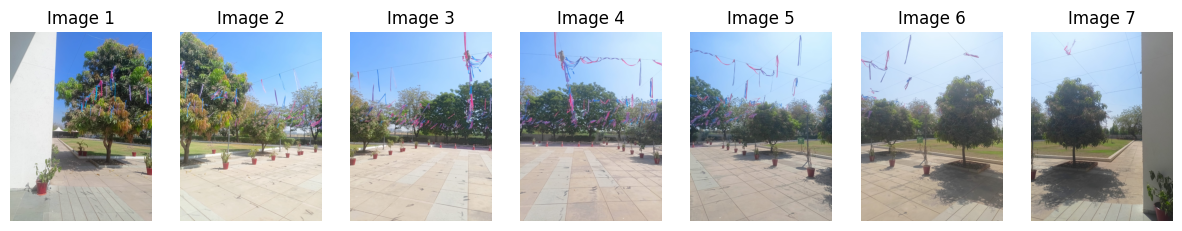

In [ ]:
images = load_images(IMAGE_FOLDER)

print("Total images:",len(images))

show_images(images)

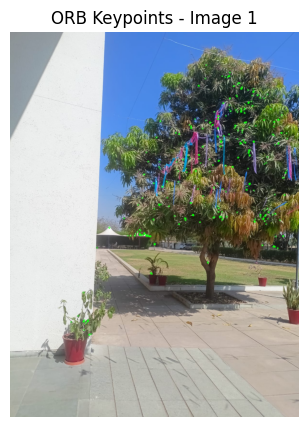

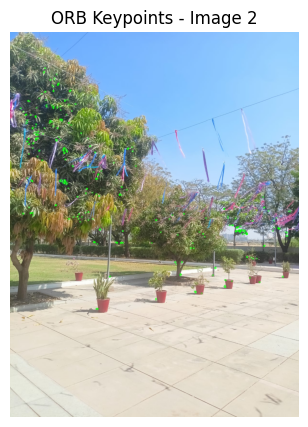

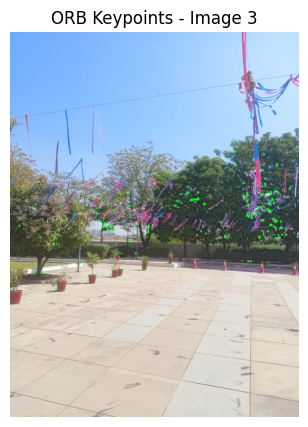

In [ ]:
for i in range(min(3,len(images))):

    orb = cv2.ORB_create()

    kp = orb.detect(images[i], None)

    img_kp = cv2.drawKeypoints(images[i], kp, None, color=(0,255,0))

    plt.figure(figsize=(8,5))
    plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
    plt.title(f"ORB Keypoints - Image {i+1}")
    plt.axis("off")

In [ ]:
def detect_and_match_features(img1,img2):

    gray1=cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
    gray2=cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

    orb=cv2.ORB_create(nfeatures=2000)

    kp1,des1=orb.detectAndCompute(gray1,None)
    kp2,des2=orb.detectAndCompute(gray2,None)

    bf=cv2.BFMatcher(cv2.NORM_HAMMING)

    matches=bf.knnMatch(des1,des2,k=2)

    good=[]

    for m,n in matches:
        if m.distance<0.75*n.distance:
            good.append(m)

    return kp1,kp2,good

Total Matches: 145


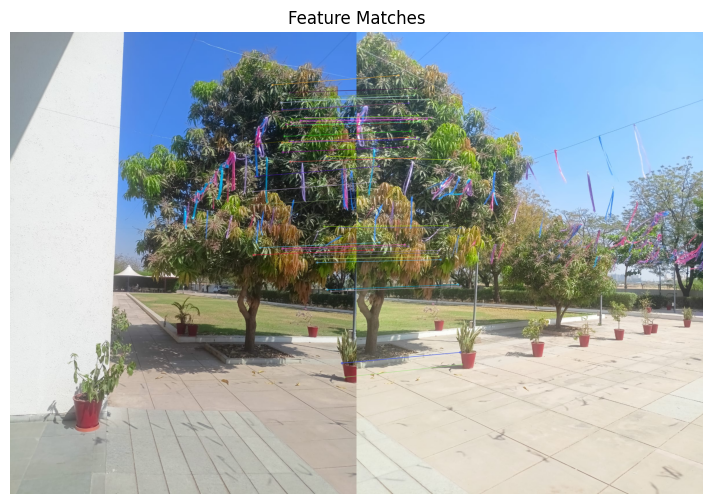

In [ ]:
kp1,kp2,good=detect_and_match_features(images[0],images[1])

match_img=cv2.drawMatches(
    images[0],kp1,
    images[1],kp2,
    good[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(14,6))
plt.imshow(cv2.cvtColor(match_img,cv2.COLOR_BGR2RGB))
plt.title("Feature Matches")
plt.axis("off")

print("Total Matches:",len(good))

In [ ]:
def compute_homography(kp1, kp2, good):

    if len(good) < 10:
        print("Not enough matches")
        return None, None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    print("Homography Matrix:\n", H)

    return H, mask

In [ ]:
H, mask = compute_homography(kp1, kp2, good)

Homography Matrix:
 [[ 2.11166879e+00 -4.77800392e-02 -1.64826909e+03]
 [ 7.46301513e-01  1.86492117e+00 -7.48784917e+02]
 [ 8.90224400e-04 -2.65950703e-07  1.00000000e+00]]


(np.float64(-0.5), np.float64(2399.5), np.float64(1599.5), np.float64(-0.5))

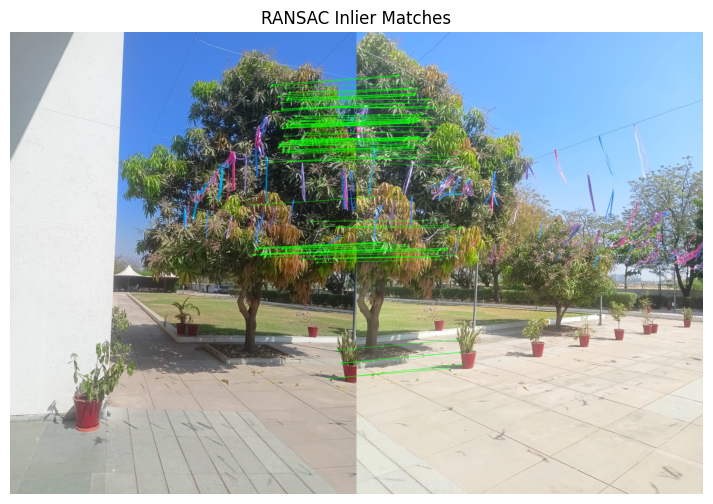

In [ ]:
# Draw only RANSAC inlier matches

matchesMask = mask.ravel().tolist()

draw_params = dict(
    matchColor = (0,255,0), # green = inliers
    singlePointColor = None,
    matchesMask = matchesMask,
    flags = 2
)

inlier_img = cv2.drawMatches(
    images[0], kp1,
    images[1], kp2,
    good,
    None,
    **draw_params
)

plt.figure(figsize=(14,6))
plt.imshow(cv2.cvtColor(inlier_img, cv2.COLOR_BGR2RGB))
plt.title("RANSAC Inlier Matches")
plt.axis("off")

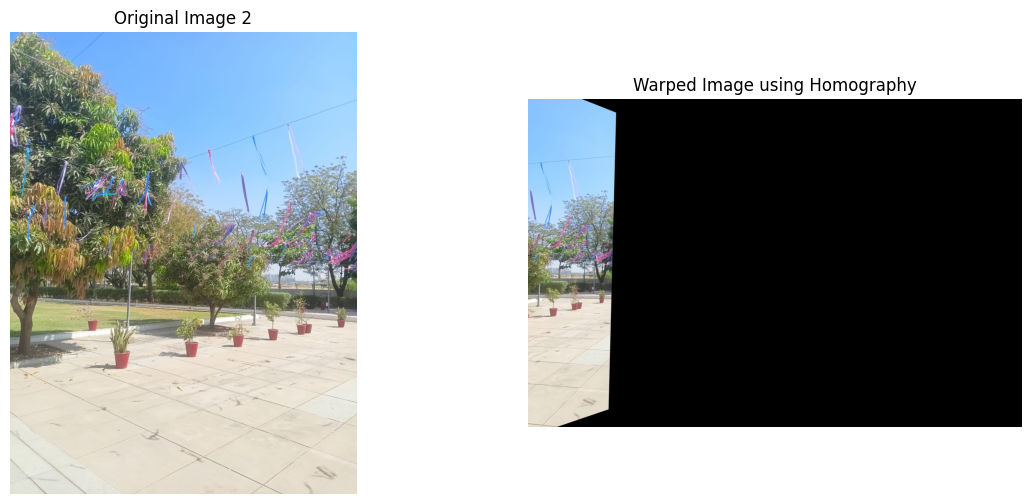

In [ ]:
h1, w1 = images[0].shape[:2]
h2, w2 = images[1].shape[:2]

# Warp second image
warped = cv2.warpPerspective(images[1], H, (w1 + w2, h1))

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(images[1], cv2.COLOR_BGR2RGB))
plt.title("Original Image 2")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Warped Image using Homography")
plt.axis("off")

plt.show()

In [ ]:
def sequential_stitch(images):

    panorama = images[0]

    for i in range(1, len(images)):

        print(f"Stitching image {i}...")

        img1 = panorama
        img2 = images[i]

        kp1, kp2, good = detect_and_match_features(img1, img2)

        if len(good) < 10:
            print("Not enough matches")
            continue

        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)

        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]

        result = cv2.warpPerspective(img2, H, (w1 + w2, h1))

        result[0:h1, 0:w1] = img1

        panorama = result

    return panorama

Stitching image 1...
Stitching image 2...
Not enough matches
Stitching image 3...
Not enough matches
Stitching image 4...
Stitching image 5...
Not enough matches
Stitching image 6...
Not enough matches


(np.float64(-0.5), np.float64(3599.5), np.float64(1599.5), np.float64(-0.5))

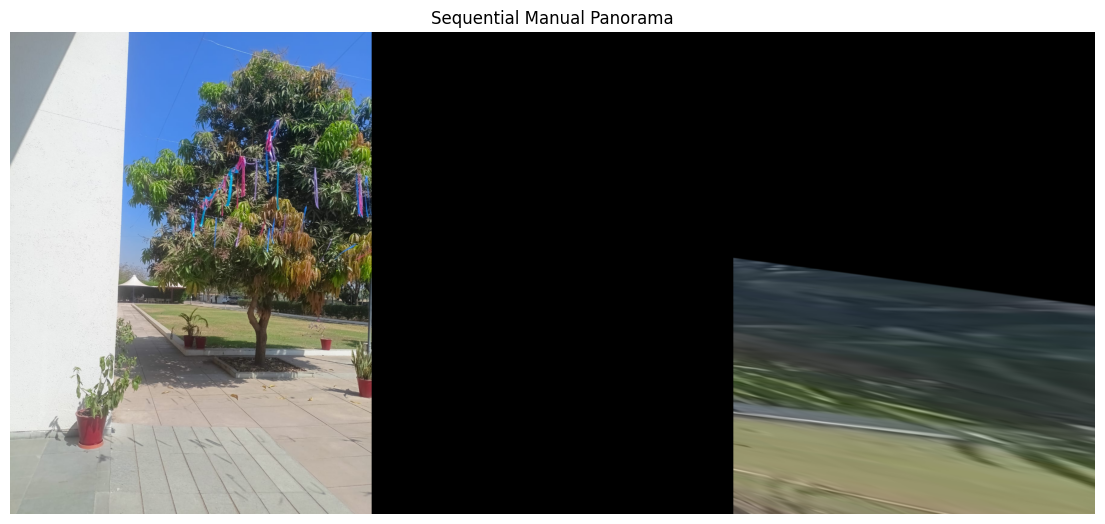

In [ ]:
manual_panorama = sequential_stitch(images)

plt.figure(figsize=(14,8))
plt.imshow(cv2.cvtColor(manual_panorama, cv2.COLOR_BGR2RGB))
plt.title("Sequential Manual Panorama")
plt.axis("off")

Running OpenCV Stitcher...


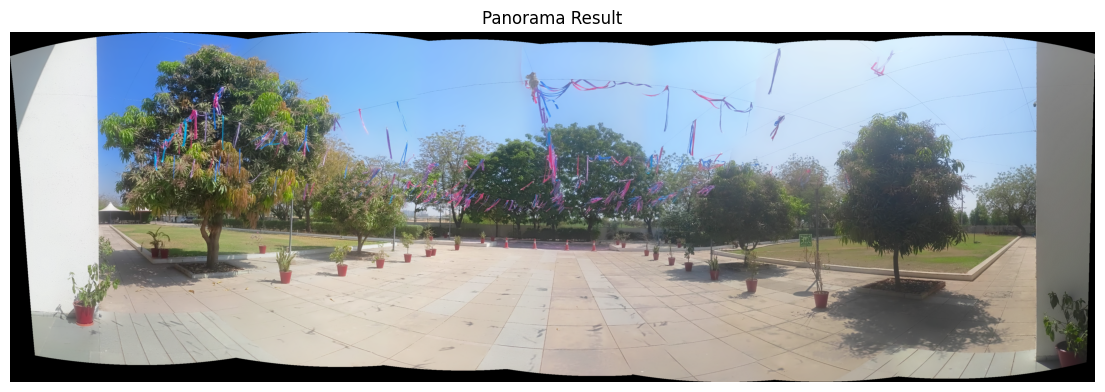

In [ ]:
print("Running OpenCV Stitcher...")

stitcher=cv2.Stitcher_create()

status,pano=stitcher.stitch(images)

if status==cv2.Stitcher_OK:

    plt.figure(figsize=(14,8))
    plt.imshow(cv2.cvtColor(pano,cv2.COLOR_BGR2RGB))
    plt.title("Panorama Result")
    plt.axis("off")

else:
    print("Stitching failed. Status:",status)


Trying SCANS mode + exposure compensation...


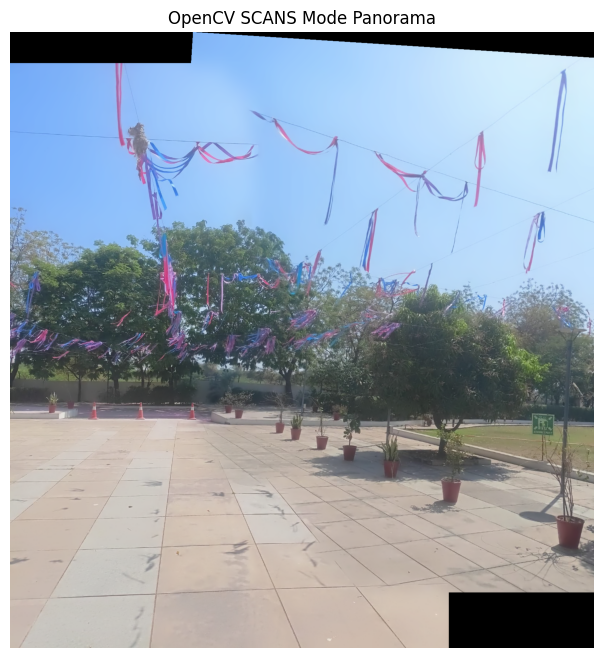

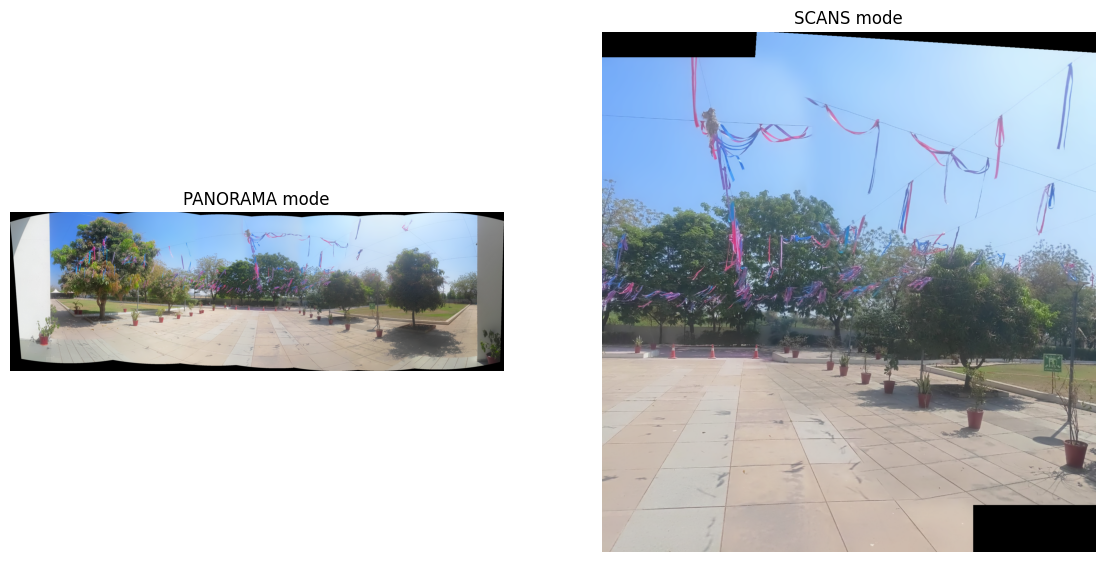

Lab completed!


In [ ]:
print("\nTrying SCANS mode + exposure compensation...")

stitcher_scans = cv2.Stitcher_create(cv2.Stitcher_SCANS)

status_scans, pano_scans = stitcher_scans.stitch(images)

if status_scans == cv2.Stitcher_OK:

    plt.figure(figsize=(14,8))
    plt.imshow(cv2.cvtColor(pano_scans, cv2.COLOR_BGR2RGB))
    plt.title("OpenCV SCANS Mode Panorama")
    plt.axis("off")

else:
    print("SCANS mode failed")

# Compare results
if 'pano' in locals() and 'pano_scans' in locals():

    plt.figure(figsize=(14,8))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title("PANORAMA mode")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(pano_scans, cv2.COLOR_BGR2RGB))
    plt.title("SCANS mode")
    plt.axis("off")

    plt.show()

print("Lab completed!")

# Deep Stitch

In [ ]:
!pip install kornia

In [ ]:
import torch
import kornia as K
import kornia.feature as KF

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
matcher = KF.LoFTR(pretrained="outdoor").eval().cuda()

In [ ]:
# Resize images for LoFTR (VERY IMPORTANT)

img1 = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(images[1], cv2.COLOR_BGR2GRAY)

img1 = cv2.resize(img1, (640,480))
img2 = cv2.resize(img2, (640,480))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

matcher = KF.LoFTR(pretrained="outdoor").eval().to(device)

img1_t = torch.tensor(img1/255.).float()[None,None].to(device)
img2_t = torch.tensor(img2/255.).float()[None,None].to(device)

input_dict = {"image0": img1_t, "image1": img2_t}

with torch.no_grad():
    correspondences = matcher(input_dict)

mkpts0 = correspondences["keypoints0"].cpu().numpy()
mkpts1 = correspondences["keypoints1"].cpu().numpy()

print("Deep matches:", len(mkpts0))

Deep matches: 973


In [ ]:
# Get original sizes
h_orig, w_orig = images[0].shape[:2]

# Get resized sizes
h_res, w_res = img1.shape[:2]

scale_x = w_orig / w_res
scale_y = h_orig / h_res

# Rescale deep keypoints
mkpts0[:,0] *= scale_x
mkpts0[:,1] *= scale_y

mkpts1[:,0] *= scale_x
mkpts1[:,1] *= scale_y

In [ ]:
src_pts = mkpts1.reshape(-1,1,2)   # image2
dst_pts = mkpts0.reshape(-1,1,2)   # image1

H_deep, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)

print("Deep Homography Matrix:\n", H_deep)

Deep Homography Matrix:
 [[ 4.90161937e-01 -1.85957566e-02  7.80500569e+02]
 [-3.50137344e-01  8.77931475e-01  9.12795249e+01]
 [-4.24700852e-04 -2.86962763e-05  1.00000000e+00]]


(np.float64(-0.5), np.float64(2399.5), np.float64(1599.5), np.float64(-0.5))

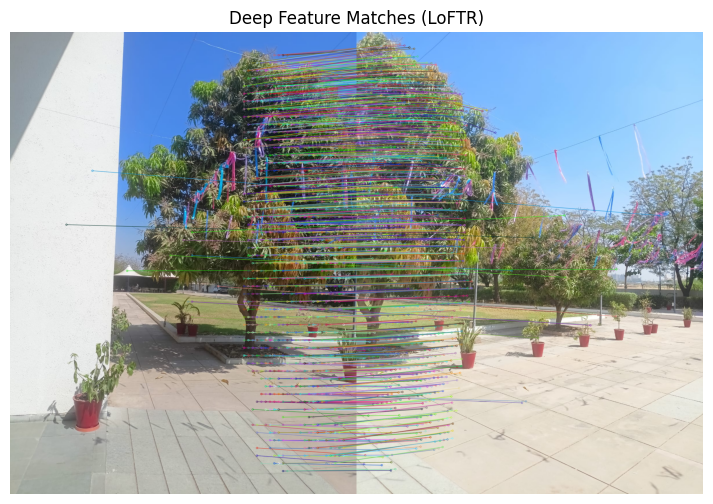

In [ ]:
match_img = cv2.drawMatches(
    images[0], [cv2.KeyPoint(x[0],x[1],1) for x in mkpts0],
    images[1], [cv2.KeyPoint(x[0],x[1],1) for x in mkpts1],
    [cv2.DMatch(i,i,0) for i in range(len(mkpts0))],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(14,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Deep Feature Matches (LoFTR)")
plt.axis("off")

(np.float64(-0.5), np.float64(2399.5), np.float64(1599.5), np.float64(-0.5))

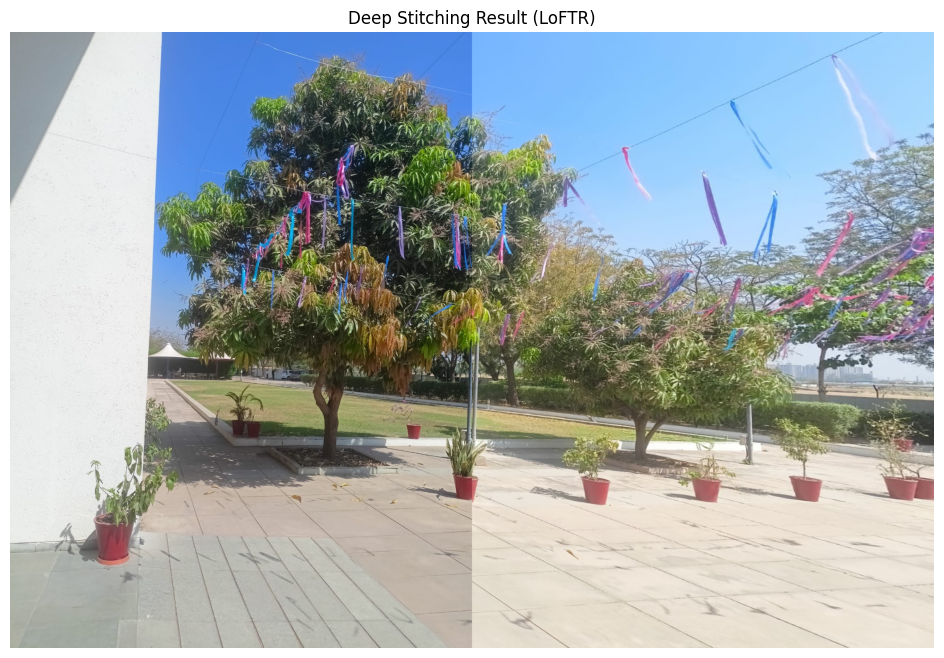

In [ ]:
h1, w1 = images[0].shape[:2]

deep_result = cv2.warpPerspective(images[1], H_deep, (w1*2, h1))

deep_result[0:h1,0:w1] = images[0]

plt.figure(figsize=(14,8))
plt.imshow(cv2.cvtColor(deep_result, cv2.COLOR_BGR2RGB))
plt.title("Deep Stitching Result (LoFTR)")
plt.axis("off")

In [ ]:
def deep_stitch_all(images):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    matcher = KF.LoFTR(pretrained="outdoor").eval().to(device)

    panorama = images[0]

    for i in range(1, len(images)):

        print("Stitching image", i)

        img1 = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)

        # resize for LoFTR (important for memory)
        img1 = cv2.resize(img1,(640,480))
        img2 = cv2.resize(img2,(640,480))

        img1_t = torch.tensor(img1/255.).float()[None,None].to(device)
        img2_t = torch.tensor(img2/255.).float()[None,None].to(device)

        input_dict = {"image0":img1_t,"image1":img2_t}

        with torch.no_grad():
            correspondences = matcher(input_dict)

        mkpts0 = correspondences["keypoints0"].cpu().numpy()
        mkpts1 = correspondences["keypoints1"].cpu().numpy()

        # compute homography
        src_pts = mkpts1.reshape(-1,1,2)
        dst_pts = mkpts0.reshape(-1,1,2)

        H,_ = cv2.findHomography(src_pts,dst_pts,cv2.RANSAC,5.0)

        h1,w1 = panorama.shape[:2]

        result = cv2.warpPerspective(images[i],H,(w1*2,h1))
        result[0:h1,0:w1] = panorama

        panorama = result

    return panorama

Stitching image 1
Stitching image 2
Stitching image 3
Stitching image 4
Stitching image 5
Stitching image 6


(np.float64(-0.5), np.float64(76799.5), np.float64(1599.5), np.float64(-0.5))

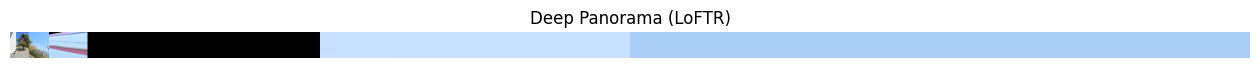

In [ ]:
deep_panorama = deep_stitch_all(images)

plt.figure(figsize=(16,8))
plt.imshow(cv2.cvtColor(deep_panorama, cv2.COLOR_BGR2RGB))
plt.title("Deep Panorama (LoFTR)")
plt.axis("off")

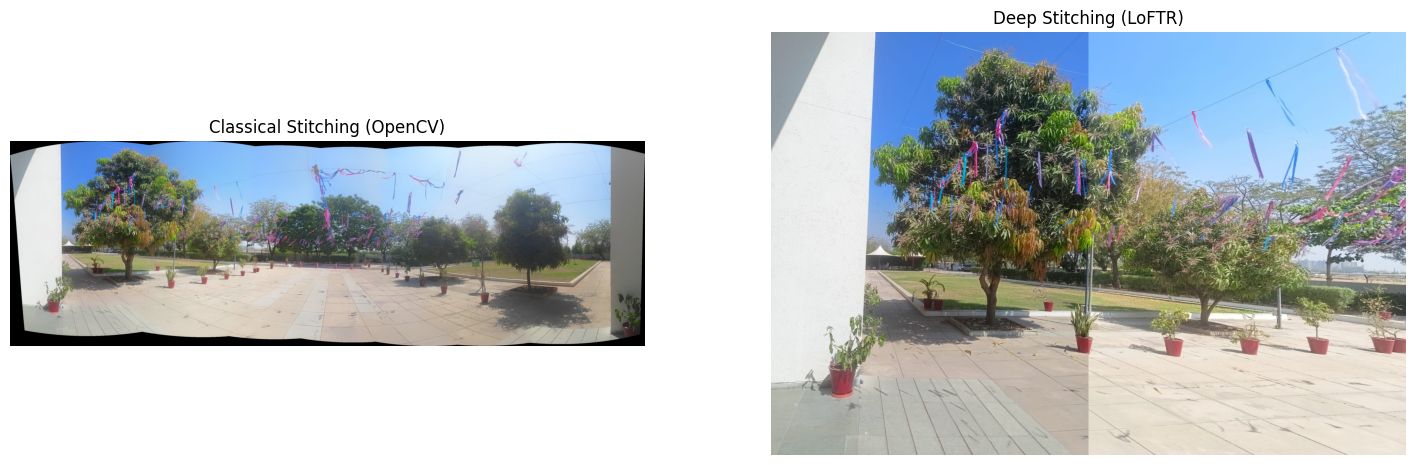

In [ ]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
plt.title("Classical Stitching (OpenCV)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(deep_result, cv2.COLOR_BGR2RGB))
plt.title("Deep Stitching (LoFTR)")
plt.axis("off")

plt.show()